<a href="https://colab.research.google.com/github/sahajp246-cpu/100-days-of-machine-learning/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
with zipfile.ZipFile('/content/archive (3).zip', 'r') as z:
    z.extractall('/content/dataset')

os.listdir('/content/dataset')

['Clean_Dataset.csv', 'business.csv', 'economy.csv']

In [ ]:
df = pd.read_csv('/content/dataset/business.csv')
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220"
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450"
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690"


In [ ]:
df.columns


Index(['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from',
       'time_taken', 'stop', 'arr_time', 'to', 'price', 'duration_mins',
       'dep_time_category'],
      dtype='object')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               93487 non-null  datetime64[ns]
 1   airline            93487 non-null  object        
 2   ch_code            93487 non-null  object        
 3   num_code           93487 non-null  int64         
 4   dep_time           93487 non-null  object        
 5   from               93487 non-null  object        
 6   time_taken         93487 non-null  object        
 7   stop               93487 non-null  object        
 8   arr_time           93487 non-null  object        
 9   to                 93487 non-null  object        
 10  price              93487 non-null  int64         
 11  duration_mins      93487 non-null  int64         
 12  dep_time_category  93487 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(9)
memory usage: 9.3+ 

In [ ]:
df.shape

(93487, 11)

In [ ]:
df.isnull().sum()

,0
date,0
airline,0
ch_code,0
num_code,0
dep_time,0
from,0
time_taken,0
stop,0
arr_time,0
to,0


## Cleaning

In [ ]:

df['stop'].value_counts()

,count
stop,
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t,81489
non-stop,8102
2+-stop,1083
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IDR\n\t\t\t\t\t\t\t\t\t\t\t\t,810
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IXU\n\t\t\t\t\t\t\t\t\t\t\t\t,776
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia PAT\n\t\t\t\t\t\t\t\t\t\t\t\t,257
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Patna\n\t\t\t\t\t\t\t\t\t\t\t\t,242
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia BBI\n\t\t\t\t\t\t\t\t\t\t\t\t,152
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia STV\n\t\t\t\t\t\t\t\t\t\t\t\t,93


In [ ]:
df['stop'] = df['stop'].str.replace('\n', '').str.replace('\t', '').str.strip()
df['stop'].value_counts()

,count
stop,
1-stop,81489
non-stop,8102
2+-stop,1083
1-stopVia IDR,810
1-stopVia IXU,776
1-stopVia PAT,257
1-stopVia Patna,242
1-stopVia BBI,152
1-stopVia STV,93


In [ ]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

In [ ]:
def to_minutes(t):
    try:
        parts = t.replace('h', '').replace('m', '').split()
        if len(parts) == 2:
            return int(parts[0]) * 60 + int(parts[1])
        return int(parts[0]) * 60
    except:
        return None

df['duration_mins'] = df['time_taken'].apply(to_minutes)
if df['price'].dtype == 'object':
    df['price'] = df['price'].str.replace(',', '').astype(int)

In [ ]:
df.describe()

,date,num_code,price,duration_mins
count,93487,93487.000000,93487.000000,93487.000000
mean,2022-03-07 17:48:16.458331136,780.056147,52540.081124,822.253468
min,2022-02-11 00:00:00,401.000000,12000.000000,60.000000
25%,2022-02-24 00:00:00,706.000000,45185.000000,530.000000
50%,2022-03-08 00:00:00,820.000000,53164.000000,785.000000
75%,2022-03-20 00:00:00,874.000000,60396.000000,1070.000000
max,2022-03-31 00:00:00,996.000000,123071.000000,2865.000000
std,NaN,147.616038,12969.314606,411.148768


In [ ]:
df

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,duration_mins,dep_time_category
0,2022-02-11,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,25612,120,Evening (5 PM - 8 PM)
1,2022-02-11,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,25612,135,Evening (5 PM - 8 PM)
2,2022-02-11,Air India,AI,531,20:00,Delhi,24h 45m,1-stop,20:45,Mumbai,42220,1485,Evening (5 PM - 8 PM)
3,2022-02-11,Air India,AI,839,21:25,Delhi,26h 30m,1-stop,23:55,Mumbai,44450,1590,Night (9 PM - 4 AM)
4,2022-02-11,Air India,AI,544,17:15,Delhi,06h 40m,1-stop,23:55,Mumbai,46690,400,Evening (5 PM - 8 PM)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93482,2022-03-31,Vistara,UK,822,09:45,Chennai,10h 05m,1-stop,19:50,Hyderabad,69265,605,Morning (5 AM - 11 AM)
93483,2022-03-31,Vistara,UK,826,12:30,Chennai,10h 25m,1-stop,22:55,Hyderabad,77105,625,Afternoon (12 PM - 4 PM)
93484,2022-03-31,Vistara,UK,832,07:05,Chennai,13h 50m,1-stop,20:55,Hyderabad,79099,830,Morning (5 AM - 11 AM)
93485,2022-03-31,Vistara,UK,828,07:00,Chennai,10h 00m,1-stop,17:00,Hyderabad,81585,600,Morning (5 AM - 11 AM)


In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after outlier removal: {df_filtered.shape}")

Original DataFrame shape: (93487, 13)
DataFrame shape after outlier removal: (89837, 13)


## Plots

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# sns.pairplot(df) # Commented out as it can be visually cluttered

Text(0.5, 0, 'Price (INR)')

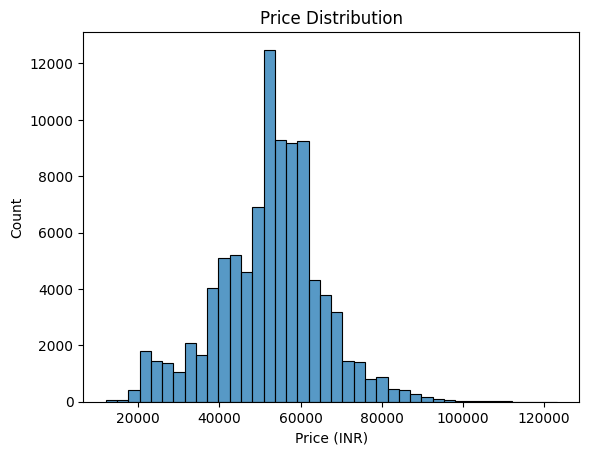

In [ ]:

sns.histplot(df['price'],bins=40)
plt.title('Price Distribution')
plt.xlabel('Price (INR)')


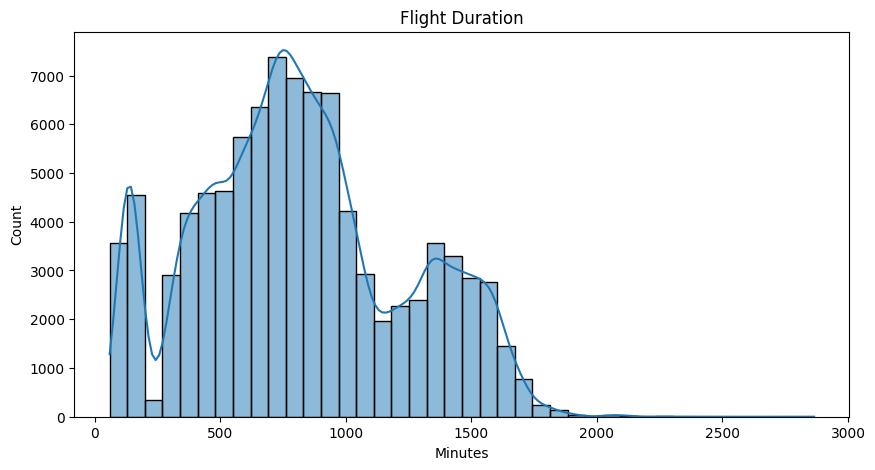

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['duration_mins'].dropna(), bins=40, kde=True)
plt.title('Flight Duration')
plt.xlabel('Minutes')
plt.show()

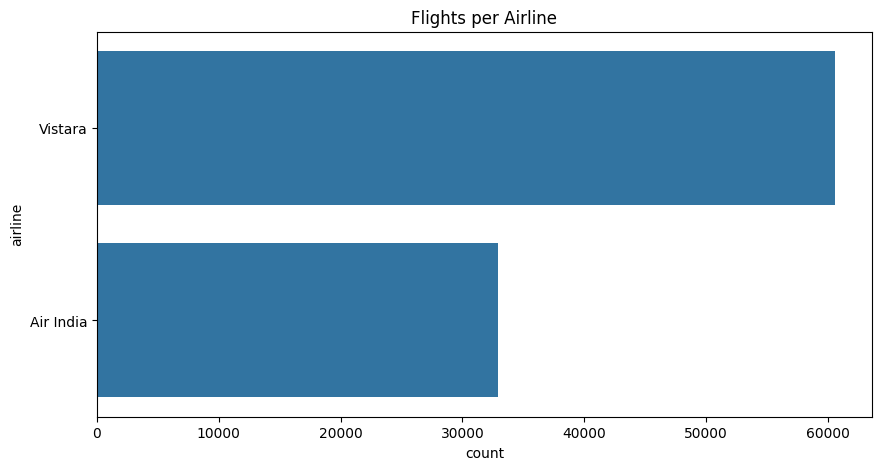

In [ ]:
plt.figure(figsize=(10, 5))
order = df['airline'].value_counts().index
sns.countplot(y='airline', data=df, order=order)
plt.title('Flights per Airline')
plt.show()

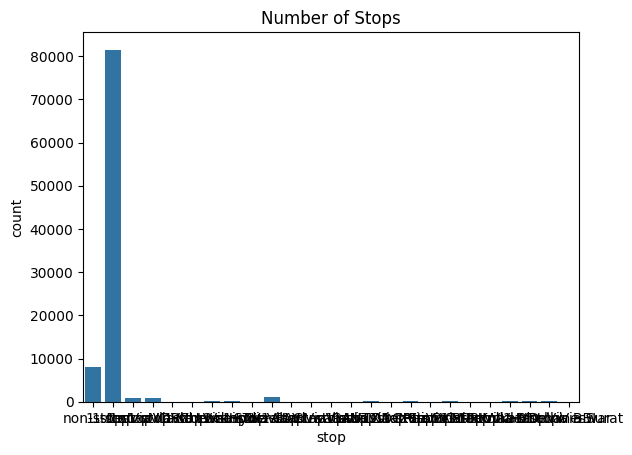

In [ ]:

order = df['stop'].value_counts().index
sns.countplot(x='stop',data=df)
plt.title('Number of Stops')
plt.show()

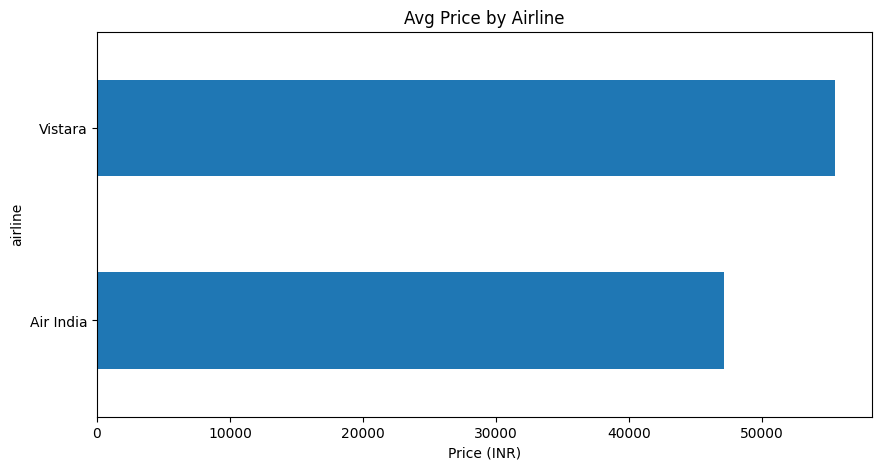

In [ ]:
plt.figure(figsize=(10, 5))
df.groupby('airline')['price'].mean().sort_values().plot(kind='barh')
plt.title('Avg Price by Airline')
plt.xlabel('Price (INR)')
plt.show()

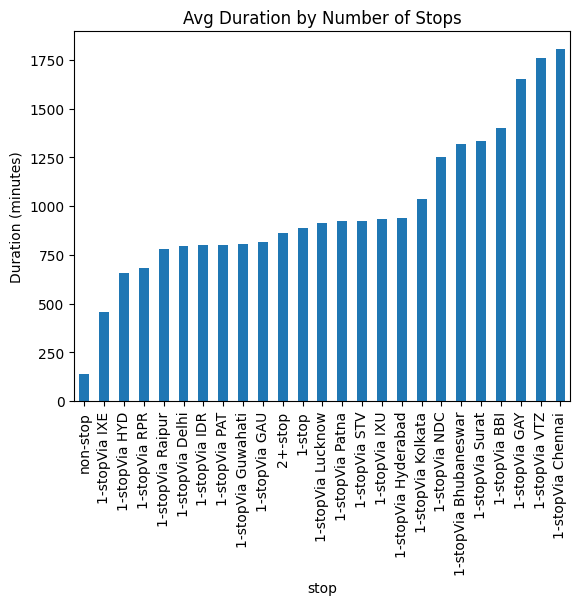

In [ ]:

df.groupby('stop')['duration_mins'].mean().sort_values().plot(kind='bar')
plt.title('Avg Duration by Number of Stops')
plt.ylabel('Duration (minutes)')

plt.show()

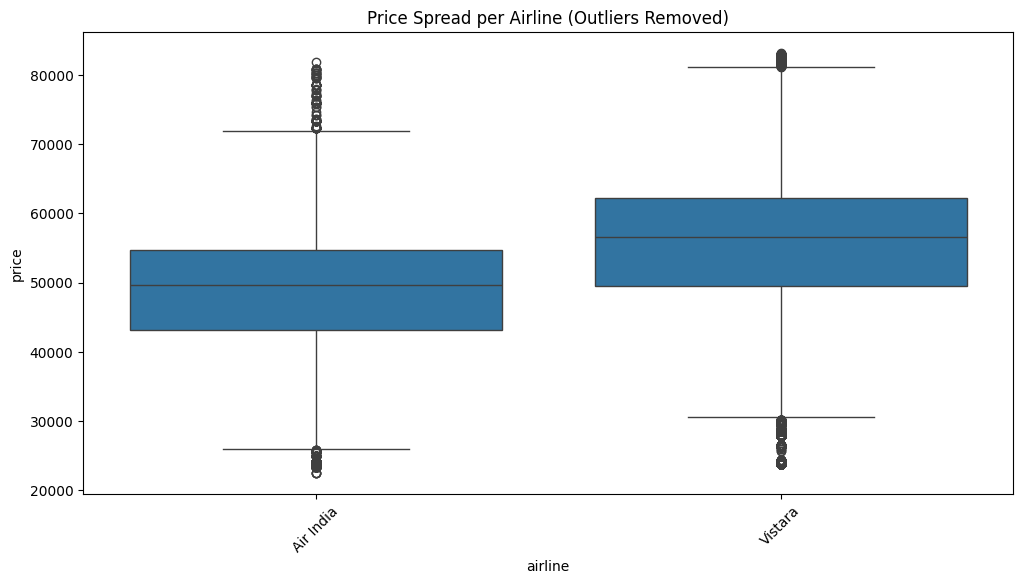

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='airline', y='price', data=df_filtered)
plt.xticks(rotation=45)
plt.title('Price Spread per Airline (Outliers Removed)')
plt.show()

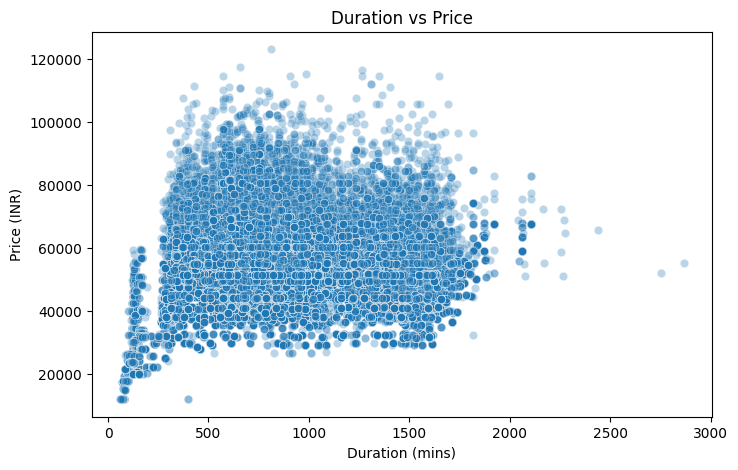

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='duration_mins', y='price', data=df, alpha=0.3)
plt.title('Duration vs Price')
plt.xlabel('Duration (mins)')
plt.ylabel('Price (INR)')
plt.show()

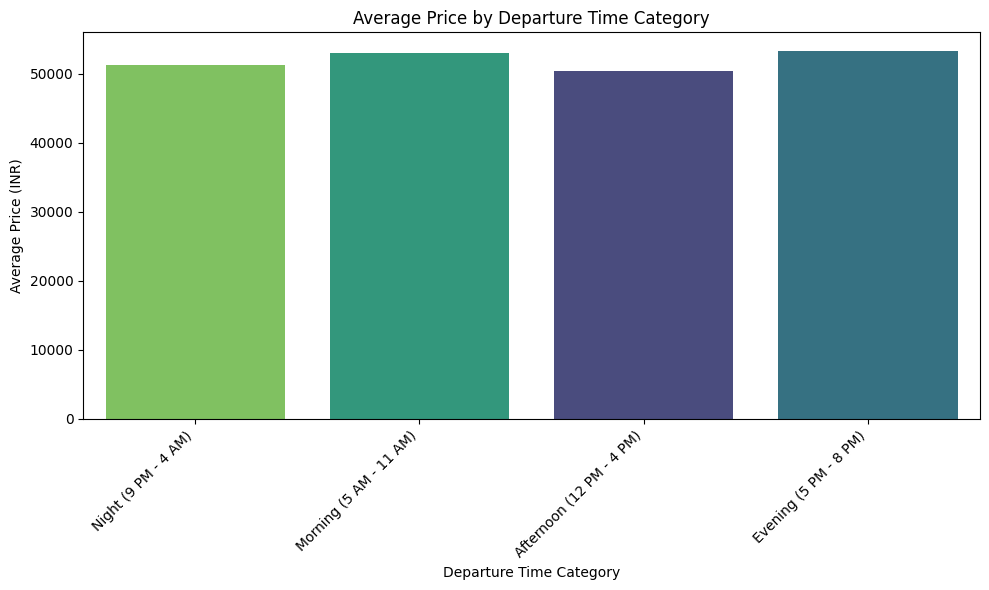

In [ ]:
def get_dep_time_category(time_str):
    hour = int(time_str.split(':')[0])
    if 5 <= hour < 12:
        return 'Morning (5 AM - 11 AM)'
    elif 12 <= hour < 17:
        return 'Afternoon (12 PM - 4 PM)'
    elif 17 <= hour < 21:
        return 'Evening (5 PM - 8 PM)'
    else:
        return 'Night (9 PM - 4 AM)'

df['dep_time_category'] = df['dep_time'].apply(get_dep_time_category)

time_category_order = ['Night (9 PM - 4 AM)', 'Morning (5 AM - 11 AM)', 'Afternoon (12 PM - 4 PM)', 'Evening (5 PM - 8 PM)']

plt.figure(figsize=(10, 6))
sns.barplot(x='dep_time_category', y='price', data=df.groupby('dep_time_category')['price'].mean().reset_index(), hue='dep_time_category', palette='viridis', order=time_category_order, legend=False)
plt.title('Average Price by Departure Time Category')
plt.xlabel('Departure Time Category')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

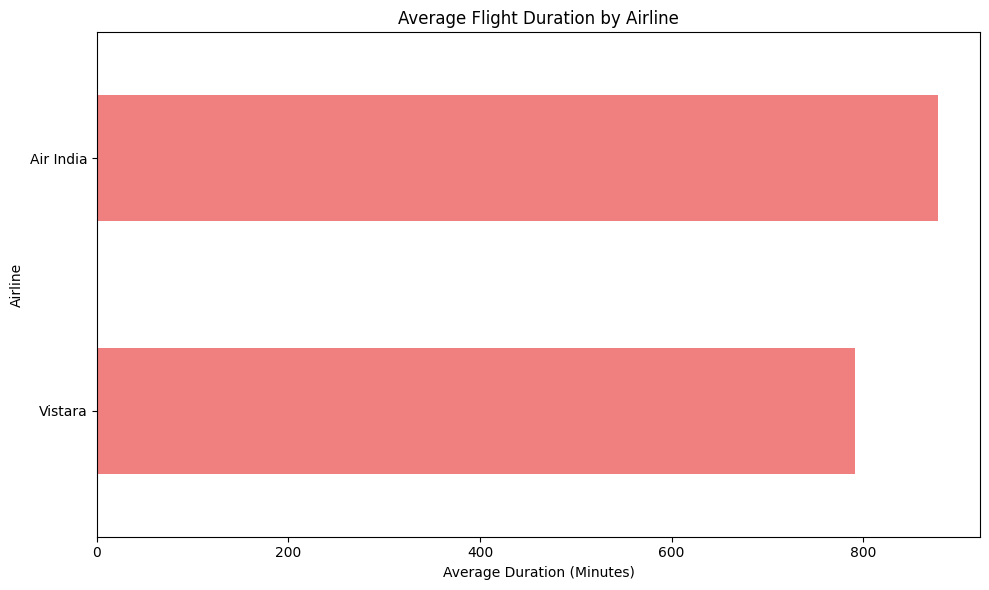

In [ ]:
plt.figure(figsize=(10, 6))
df.groupby('airline')['duration_mins'].mean().sort_values().plot(kind='barh', color='lightcoral')
plt.title('Average Flight Duration by Airline')
plt.xlabel('Average Duration (Minutes)')
plt.ylabel('Airline')
plt.tight_layout()
plt.show()

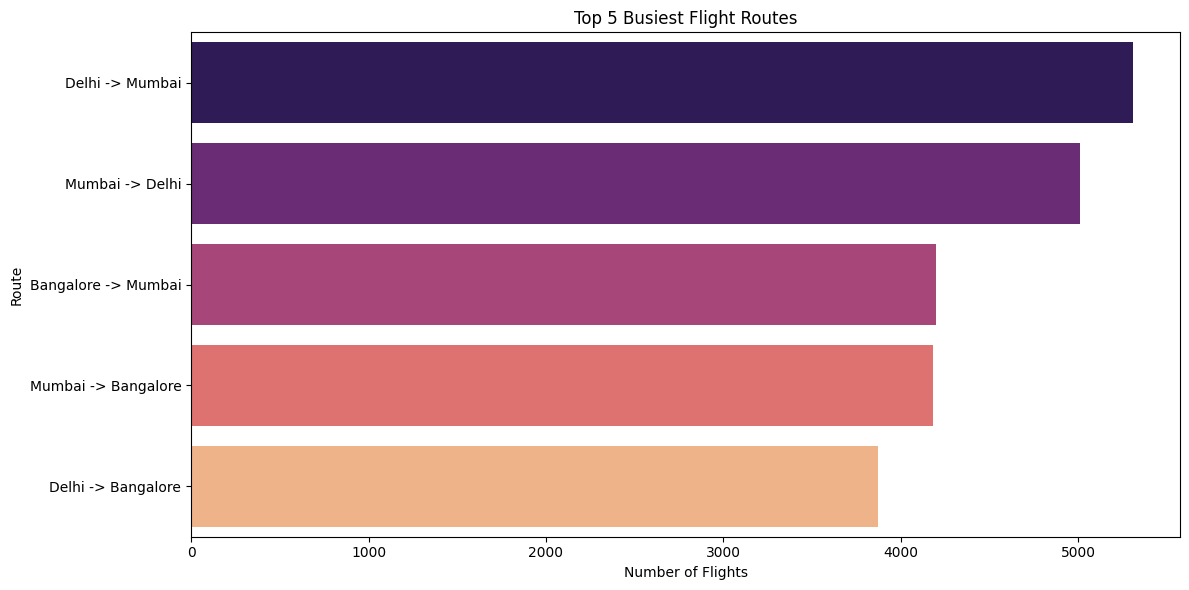

In [ ]:
route_counts = df.groupby(['from', 'to']).size().reset_index(name='flight_count')
top_busiest_routes = route_counts.sort_values('flight_count', ascending=False).head(5)
top_busiest_routes['route'] = top_busiest_routes['from'] + ' -> ' + top_busiest_routes['to']

plt.figure(figsize=(12, 6))
sns.barplot(x='flight_count', y='route', data=top_busiest_routes, hue='route', palette='magma', legend=False)
plt.title('Top 5 Busiest Flight Routes')
plt.xlabel('Number of Flights')
plt.ylabel('Route')
plt.tight_layout()
plt.show()

---
## Deeper Analysis
Using the cleaned dataset which has economy/business class, days left, source/destination cities

In [ ]:
data = pd.read_csv('/content/dataset/Clean_Dataset.csv')
data.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
data.columns.tolist()

['Unnamed: 0',
 'airline',
 'flight',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class',
 'duration',
 'days_left',
 'price']

In [ ]:
data.shape

(300153, 12)

### Q1 — Which airline charges the most on average?

In [ ]:
data.groupby('airline')['price'].mean().sort_values(ascending=False)

,price
airline,
Vistara,30396.536302
Air_India,23507.019112
SpiceJet,6179.278881
GO_FIRST,5652.007595
Indigo,5324.216303
AirAsia,4091.072742


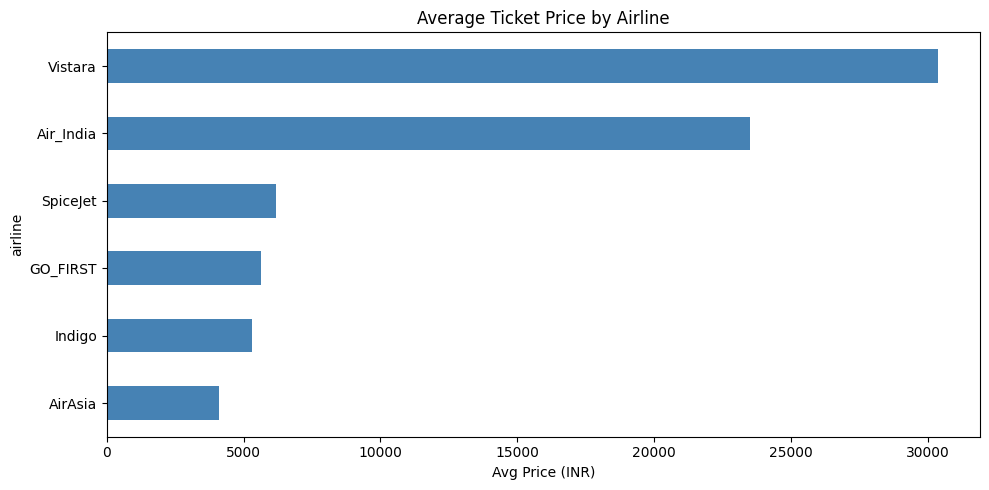

In [ ]:
plt.figure(figsize=(10, 5))
data.groupby('airline')['price'].mean().sort_values().plot(kind='barh', color='steelblue')
plt.title('Average Ticket Price by Airline')
plt.xlabel('Avg Price (INR)')
plt.tight_layout()
plt.show()

### Q2 — Does booking earlier give you cheaper tickets?

In [ ]:
# grouping days_left into buckets to see the trend more clearly
data['days_bucket'] = pd.cut(data['days_left'], bins=[0, 7, 15, 30, 60, 100, 200], labels=['0-7', '8-15', '16-30', '31-60', '61-100', '100+'])
data.groupby('days_bucket', observed=True)['price'].mean()

,price
days_bucket,
0-7,26451.234827
8-15,23534.110876
16-30,19754.193214
31-60,19260.919021


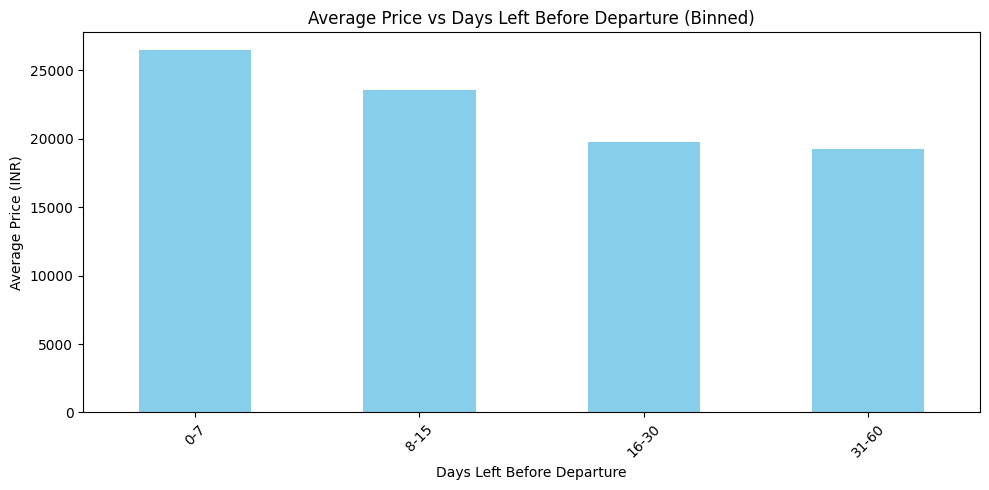

In [ ]:
plt.figure(figsize=(10, 5))
# Use the grouped data by days_bucket for a clearer trend
avg_price_by_days_bucket = data.groupby('days_bucket', observed=True)['price'].mean()
avg_price_by_days_bucket.plot(kind='bar', color='skyblue')
plt.title('Average Price vs Days Left Before Departure (Binned)')
plt.xlabel('Days Left Before Departure')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45) # Rotate labels for better readability
plt.tight_layout()
plt.show()

### Q3 — Top 5 most expensive routes

In [ ]:
routes = data.groupby(['source_city', 'destination_city'])['price'].mean().reset_index()
routes.columns = ['from', 'to', 'avg_price']
routes.sort_values('avg_price', ascending=False).head(5)

,from,to,avg_price
5,Chennai,Bangalore,25081.850454
21,Kolkata,Chennai,23660.361040
3,Bangalore,Kolkata,23500.061229
0,Bangalore,Chennai,23321.850078
25,Mumbai,Bangalore,23147.873807


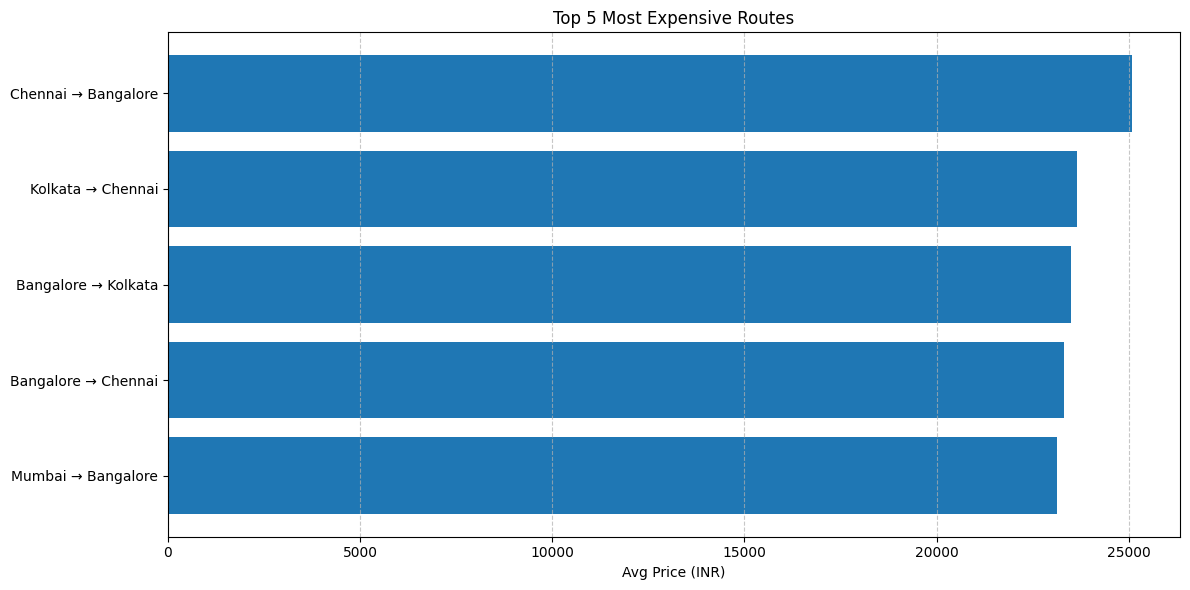

In [ ]:
top5 = routes.sort_values('avg_price', ascending=False).head(5)
top5['route'] = top5['from'] + ' → ' + top5['to']

plt.figure(figsize=(12, 6))
plt.barh(top5['route'], top5['avg_price'],)
plt.title('Top 5 Most Expensive Routes')
plt.xlabel('Avg Price (INR)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7) # Added grid for readability
plt.tight_layout()
plt.show()

### Q4 — More stops = cheaper or more expensive?

In [ ]:
data.groupby('stops')['price'].mean().sort_values()

,price
stops,
zero,9375.938535
two_or_more,14113.450775
one,22900.992482


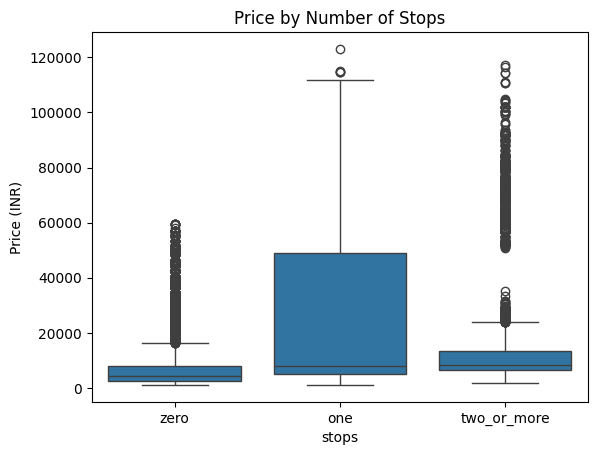

In [ ]:

sns.boxplot(x='stops', y='price', data=data)
plt.title('Price by Number of Stops')
plt.ylabel('Price (INR)')
plt.show()

### Q5 — Economy vs Business class pricing

In [ ]:
data.groupby('class')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
Business,93487.0,52540.081124,12969.314606,12000.0,45185.0,53164.0,60396.0,123071.0
Economy,206666.0,6572.342383,3743.519517,1105.0,4173.0,5772.0,7746.0,42349.0


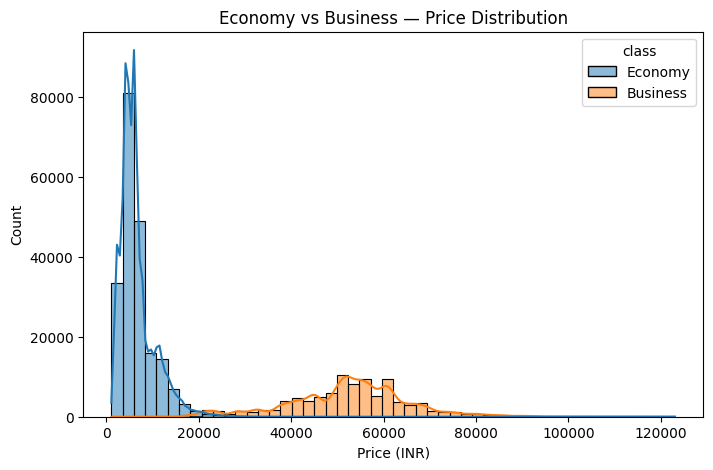

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='price', hue='class', bins=50, kde=True)
plt.title('Economy vs Business — Price Distribution')
plt.xlabel('Price (INR)')
plt.show()

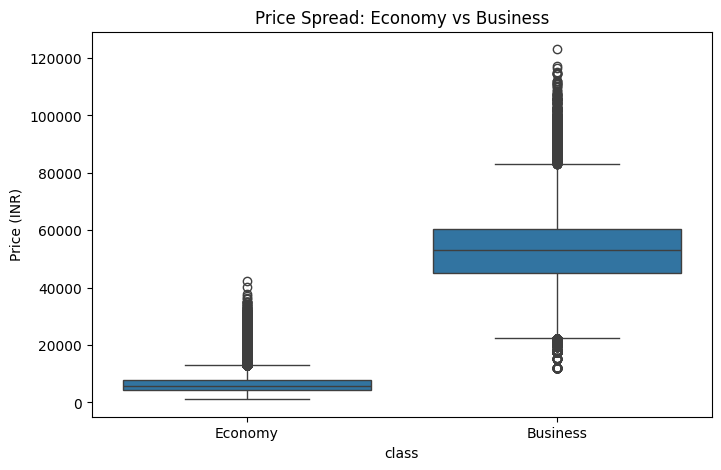

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='class', y='price', data=data)
plt.title('Price Spread: Economy vs Business')
plt.ylabel('Price (INR)')
plt.show()